## Idea

This notebook performs sequential hyperparameter tuning of the XGBoost model using Stratified Group 5-Fold Cross Validation.

Parameters are tuned in four stages:
1. Core parameters (`eta`, `max_depth`, `num_boost_round`)
2. Tree complexity (`gamma`, `min_child_weight`)
3. Sampling parameters (`subsample`, `colsample_bytree`)
4. Regularization (`reg_alpha`, `reg_lambda`)

Each stage compares four search strategies:
- Manual Search
- Random Search
- Grid Search
- Optuna Bayesian Optimization

The main evaluation metric is PR-AUC due to the highly imbalanced SIMBox fraud detection problem. All experiments, parameters, and metrics are tracked using MLflow.

---

### Imports

In [1]:
from pathlib import Path
import json
import random
from itertools import product

import mlflow
import mlflow.xgboost

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import optuna
import xgboost as xgb

from sklearn.model_selection import (
    StratifiedGroupKFold,
    ParameterGrid,
    ParameterSampler
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

### Paths + MLflow

In [ ]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v3.parquet"

MLRUNS_PATH = PROJECT_ROOT / "mlruns"

BEST_PARAMS_PATH = DATA_PATH / "results" / "best_xgb_params.json"

mlflow.set_tracking_uri(f"file:{MLRUNS_PATH}")

mlflow.set_experiment("simbox_fraud_detection")

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/181740959998191728', creation_time=1781294983928, experiment_id='181740959998191728', last_update_time=1781294983928, lifecycle_stage='active', name='simbox_fraud_detection', tags={}, trace_location=None, workspace='default'>

### Load dataset

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)

print(train_df.shape)

train_df.head()

DROP_COLUMNS = [
    "label",
    "msisdn",
    "profile_date"
]

X = train_df.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

y = train_df["label"]

groups = train_df["msisdn"]

print("Features :", X.shape)
print("Fraud    :", (y == 1).sum())
print("Normal   :", (y == 0).sum())
print("MSISDNs  :", groups.nunique())

(343040, 15)
Features : (343040, 12)
Fraud    : 19725
Normal   : 323315
MSISDNs  : 25394


### SGKF setup

In [4]:
N_SPLITS = 5

sgkf = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

### Base parameters

In [5]:
scale_pos_weight = ((y == 0).sum() / (y == 1).sum())

BASE_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",

    "eta": 0.05,
    "max_depth": 6,

    "min_child_weight": 1,
    "gamma": 0,

    "subsample": 1.0,
    "colsample_bytree": 1.0,

    "reg_alpha": 0,
    "reg_lambda": 1,

    "scale_pos_weight": scale_pos_weight,

    "seed": 42,
    "n_jobs": -1
}

NUM_BOOST_ROUND = 300

### SGFK evaluation function

In [6]:
def evaluate_params(
    params,
    num_boost_round,
    run_name=None,
    search_method=None,
    stage=None
):
    
    pr_scores = []
    roc_scores = []

    for train_idx, val_idx in sgkf.split(
        X,
        y,
        groups
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        dtrain = xgb.DMatrix(
            X_train,
            label=y_train
        )

        dval = xgb.DMatrix(
            X_val,
            label=y_val
        )

        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=num_boost_round,
            verbose_eval=False
        )

        pred = model.predict(dval)

        pr_scores.append(
            average_precision_score(
                y_val,
                pred
            )
        )

        roc_scores.append(
            roc_auc_score(
                y_val,
                pred
            )
        )

    result = {
        "run_name": run_name,
        "stage": stage,
        "search_method": search_method,

        "pr_auc_mean": np.mean(pr_scores),
        "pr_auc_std": np.std(pr_scores),

        "roc_auc_mean": np.mean(roc_scores),
        "roc_auc_std": np.std(roc_scores)
    }

    return result

### MLflow logger function

In [7]:
def log_run(
    params,
    num_boost_round,
    result
):

    with mlflow.start_run(
        run_name=result["run_name"]
    ):

        mlflow.log_input(
            mlflow.data.from_pandas(
                train_df,
                source=str(TRAIN_PATH)
            ),
            context="training"
        )

        mlflow.log_param(
            "dataset",
            "train_v3"
        )

        mlflow.log_param(
            "stage",
            result["stage"]
        )

        mlflow.log_param(
            "search_method",
            result["search_method"]
        )

        mlflow.log_param(
            "num_boost_round",
            num_boost_round
        )

        mlflow.log_params(params)

        mlflow.log_metric(
            "pr_auc_mean",
            result["pr_auc_mean"]
        )

        mlflow.log_metric(
            "pr_auc_std",
            result["pr_auc_std"]
        )

        mlflow.log_metric(
            "roc_auc_mean",
            result["roc_auc_mean"]
        )

        mlflow.log_metric(
            "roc_auc_std",
            result["roc_auc_std"]
        )

### Result and visualization functions

In [8]:
# Results table
def results_dataframe(results):

    df = pd.DataFrame(results)

    df = df.sort_values(
        "pr_auc_mean",
        ascending=False
    ).reset_index(drop=True)

    return df

# Box plot
def plot_search_comparison(results_df, stage_name):

    plt.figure(figsize=(8,6))

    methods = results_df["search_method"].unique()

    data = [
        results_df.loc[
            results_df["search_method"] == m,
            "pr_auc_mean"
        ]
        for m in methods
    ]

    plt.boxplot(
        data,
        tick_labels=methods
    )

    plt.ylabel("Mean PR-AUC")

    plt.title(
        f"{stage_name} Search Comparison"
    )

    plt.grid(True)

    plt.show()

---
## Stage 1: core parameters
- `eta`
- `n_estimators`
- `max_depth`

In [9]:
STAGE = "core_parameters"

CORE_RESULTS = []

CORE_SEARCH_SPACE = {
    "eta": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "num_boost_round": [200, 500,800]
}

# helper function
def build_params(
    tuned_params
):

    params = BASE_PARAMS.copy()

    params.update(
        {
            k: v
            for k, v in tuned_params.items()
            if k != "num_boost_round"
        }
    )

    return params

### Manual search for core parameters

In [10]:
manual_configs = [
    {
        "eta": 0.05,
        "max_depth": 5,
        "num_boost_round": 500
    },

    {
        "eta": 0.03,
        "max_depth": 5,
        "num_boost_round": 800
    },

    {
        "eta": 0.05,
        "max_depth": 7,
        "num_boost_round": 500
    },

    {
        "eta": 0.01,
        "max_depth": 5,
        "num_boost_round": 800
    }
]


for i, config in enumerate(manual_configs):

    params = build_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=config["num_boost_round"],
        run_name=f"stage1_manual_{i}",
        search_method="manual",
        stage=STAGE
    )

    result.update(config)

    CORE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=config["num_boost_round"],
        result=result
    )


print("Manual search completed")

2026/07/17 01:49:29 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_re

Manual search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Random search for core parameters

In [11]:
random_param_grid = {
    "eta": [0.01, 0.02, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7,8],
    "num_boost_round": [200, 300, 500, 700, 900]
}


random_configs = list(
    ParameterSampler(
        random_param_grid,
        n_iter=15,
        random_state=42
    )
)

print(f"Number of configs: {len(random_configs)}")

for i, config in enumerate(random_configs):

    params = build_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=config["num_boost_round"],
        run_name=f"stage1_random_{i}",
        search_method="random",
        stage=STAGE
    )

    result.update(config)

    CORE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=config["num_boost_round"],
        result=result
    )


print("Random search completed")

Number of configs: 15


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Random search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Grid search for core parameters

In [12]:
grid_configs = list(
    ParameterGrid({
        "eta": [0.01, 0.03, 0.05],
        "max_depth": [4, 5, 6],
        "num_boost_round": [300, 500]
    })
)

print(f"Number of configs: {len(grid_configs)}")

for i, config in enumerate(grid_configs):

    params = build_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=config["num_boost_round"],
        run_name=f"stage1_grid_{i}",
        search_method="grid",
        stage=STAGE
    )

    result.update(config)
    CORE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=config["num_boost_round"],
        result=result
    )

print("Grid search completed")

Number of configs: 18


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Grid search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Optuna for core parameters

In [13]:
def optuna_core_objective(trial):

    config = {
        "eta": trial.suggest_float(
            "eta",
            0.01,
            0.1,
            log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            8
        ),
        "num_boost_round": trial.suggest_int(
            "num_boost_round",
            200,
            900,
            step=100
        )
    }

    params = build_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=config["num_boost_round"],
        run_name=f"stage1_optuna_{trial.number}",
        search_method="optuna",
        stage=STAGE
    )

    result.update(config)
    CORE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=config["num_boost_round"],
        result=result
    )

    return result["pr_auc_mean"]

# Run optuna
study = optuna.create_study(
    direction="maximize",
    study_name="stage1_core_parameters"
)

study.optimize(
    optuna_core_objective,
    n_trials=50
)

print(study.best_params)
print(study.best_value)

[I 2026-07-17 02:08:02,432] A new study created in memory with name: stage1_core_parameters
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer

{'eta': 0.04679268676711243, 'max_depth': 4, 'num_boost_round': 700}
0.43048883826508444


### Stage 1 results and comparison

,run_name,stage,search_method,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,eta,max_depth,num_boost_round
0,stage1_optuna_41,core_parameters,optuna,0.430489,0.010582,0.867628,0.002880,0.046793,4,700
1,stage1_optuna_37,core_parameters,optuna,0.430238,0.010675,0.867379,0.002916,0.035607,4,700
2,stage1_optuna_42,core_parameters,optuna,0.430227,0.010463,0.867632,0.002920,0.047229,4,700
3,stage1_optuna_34,core_parameters,optuna,0.430173,0.010766,0.867267,0.002949,0.032309,4,800
4,stage1_optuna_31,core_parameters,optuna,0.430124,0.011135,0.867394,0.002912,0.040375,5,600
5,stage1_optuna_4,core_parameters,optuna,0.430107,0.011048,0.867382,0.002693,0.032981,5,700
6,stage1_optuna_24,core_parameters,optuna,0.430106,0.011261,0.867266,0.002802,0.039288,5,500
7,stage1_optuna_33,core_parameters,optuna,0.430105,0.010742,0.867437,0.002687,0.031782,5,800
8,stage1_optuna_16,core_parameters,optuna,0.430104,0.011395,0.866946,0.002820,0.025277,6,600
9,stage1_grid_13,core_parameters,grid,0.430067,0.010775,0.867293,0.002924,0.050000,4,500


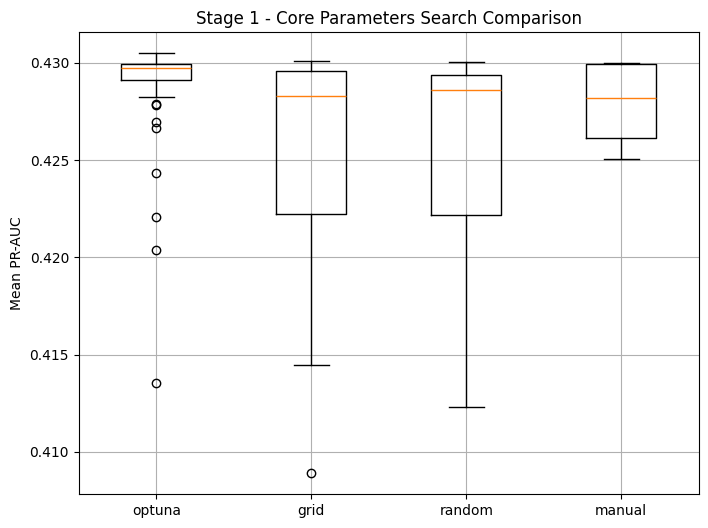

In [14]:
core_results_df = results_dataframe(
    CORE_RESULTS
)

# Top results table
display(
    core_results_df.head(15)
)

# Variance box plot
plot_search_comparison(
    core_results_df,
    "Stage 1 - Core Parameters"
)

### Select & freeze best core parameters

In [15]:
# Select
best_core = (
    core_results_df
    .iloc[0]
)

BEST_STAGE1_PARAMS = {
    "eta": best_core["eta"],
    "max_depth": int(best_core["max_depth"]),
    "num_boost_round": int(best_core["num_boost_round"])
}

BEST_STAGE1_PARAMS

# Freeze
STAGE1_PARAMS = BASE_PARAMS.copy()

STAGE1_PARAMS.update(
    {
        "eta": BEST_STAGE1_PARAMS["eta"],
        "max_depth": BEST_STAGE1_PARAMS["max_depth"]
    }
)

STAGE1_BOOST_ROUND = BEST_STAGE1_PARAMS["num_boost_round"]

STAGE1_PARAMS

{'objective': 'binary:logistic',
 'eval_metric': 'aucpr',
 'eta': np.float64(0.04679268676711243),
 'max_depth': 4,
 'min_child_weight': 1,
 'gamma': 0,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'reg_alpha': 0,
 'reg_lambda': 1,
 'scale_pos_weight': np.float64(16.39112801013942),
 'seed': 42,
 'n_jobs': -1}

---
## Stage 2: tree complexity
- `gamma`
- `min_child_weight`

In [16]:
STAGE = "tree_complexity"

TREE_RESULTS = []

def build_stage2_params(tuned_params):

    params = STAGE1_PARAMS.copy()

    params.update(
        {
            k: v
            for k, v in tuned_params.items()
        }
    )

    return params

### Manual search for tree parameters

In [17]:
manual_configs = [
    {"gamma": 0, "min_child_weight": 1},
    {"gamma": 1, "min_child_weight": 3},
    {"gamma": 5, "min_child_weight": 5},
    {"gamma": 1, "min_child_weight": 10}
]

for i, config in enumerate(manual_configs):

    params = build_stage2_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage2_manual_{i}",
        search_method="manual",
        stage=STAGE
    )

    result.update(config)
    TREE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Manual search completed")

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Manual search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Random search for tree parameters

In [18]:
random_configs = list(
    ParameterSampler(
        {
            "gamma": [0, 0.5, 1, 2, 5, 10],
            "min_child_weight": [1, 3, 5, 10, 15, 20]
        },
        n_iter=15,
        random_state=42
    )
)

print(f"Number of configs: {len(random_configs)}")

for i, config in enumerate(random_configs):

    params = build_stage2_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage2_random_{i}",
        search_method="random",
        stage=STAGE
    )

    result.update(config)
    TREE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Random search completed")

Number of configs: 15


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Random search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Grid search for tree parameters

In [19]:
grid_configs = list(
    ParameterGrid(
        {
            "gamma": [0, 1, 5],
            "min_child_weight": [1, 5, 10]
        }
    )
)

print("Number of configs: {len(grid_configs)}")

for i, config in enumerate(grid_configs):

    params = build_stage2_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage2_grid_{i}",
        search_method="grid",
        stage=STAGE
    )

    result.update(config)
    TREE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Grid search completed")

Number of configs: {len(grid_configs)}


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Grid search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Optuna for tree parameters

In [20]:
def optuna_tree_objective(trial):

    config = {
        "gamma": trial.suggest_float(
            "gamma",
            0,
            10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            20
        )
    }

    params = build_stage2_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage2_optuna_{trial.number}",
        search_method="optuna",
        stage=STAGE
    )

    result.update(config)
    TREE_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

    return result["pr_auc_mean"]

# Run optuna
study = optuna.create_study(
    direction="maximize",
    study_name="stage2_tree_complexity"
)

study.optimize(
    optuna_tree_objective,
    n_trials=50
)

print(study.best_params)
print(study.best_value)

[I 2026-07-17 02:49:41,165] A new study created in memory with name: stage2_tree_complexity
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer

{'gamma': 2.7183857666161955, 'min_child_weight': 11}
0.4305009875940577


### Stage 2 results and comparison

,run_name,stage,search_method,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,gamma,min_child_weight
0,stage2_random_10,tree_complexity,random,0.430556,0.010660,0.867728,0.002890,0.500000,10
1,stage2_optuna_12,tree_complexity,optuna,0.430501,0.010741,0.867580,0.002945,2.718386,11
2,stage2_random_12,tree_complexity,random,0.430489,0.010582,0.867628,0.002880,0.000000,1
3,stage2_grid_0,tree_complexity,grid,0.430489,0.010582,0.867628,0.002880,0.000000,1
4,stage2_manual_0,tree_complexity,manual,0.430489,0.010582,0.867628,0.002880,0.000000,1
5,stage2_optuna_48,tree_complexity,optuna,0.430472,0.010678,0.867639,0.002995,2.816240,12
6,stage2_optuna_23,tree_complexity,optuna,0.430463,0.010671,0.867561,0.002950,1.919758,9
7,stage2_optuna_45,tree_complexity,optuna,0.430427,0.010718,0.867489,0.003017,3.510401,12
8,stage2_random_13,tree_complexity,random,0.430426,0.010680,0.867733,0.002836,0.000000,15
9,stage2_optuna_7,tree_complexity,optuna,0.430424,0.010561,0.867549,0.002840,2.931847,10


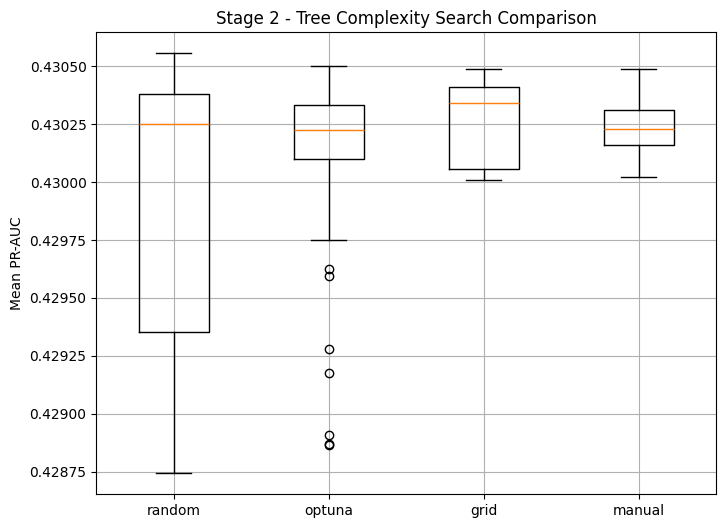

In [21]:
tree_results_df = results_dataframe(
    TREE_RESULTS
)

# Top results table
display(
    tree_results_df.head(15)
)

# Variance box plot
plot_search_comparison(
    tree_results_df,
    "Stage 2 - Tree Complexity"
)

### Select & freeze best tree parameters

In [22]:
best_tree = tree_results_df.iloc[0]

STAGE2_PARAMS = STAGE1_PARAMS.copy()

STAGE2_PARAMS.update(
    {
        "gamma": best_tree["gamma"],
        "min_child_weight": int(
            best_tree["min_child_weight"]
        )
    }
)

STAGE2_PARAMS

{'objective': 'binary:logistic',
 'eval_metric': 'aucpr',
 'eta': np.float64(0.04679268676711243),
 'max_depth': 4,
 'min_child_weight': 10,
 'gamma': np.float64(0.5),
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'reg_alpha': 0,
 'reg_lambda': 1,
 'scale_pos_weight': np.float64(16.39112801013942),
 'seed': 42,
 'n_jobs': -1}

---
## Stage 3: sampling parameters
- `subsample`
- `colsample_bytree`

In [23]:
STAGE = "sampling"

SAMPLING_RESULTS = []

def build_stage3_params(tuned_params):

    params = STAGE2_PARAMS.copy()

    params.update(
        tuned_params
    )

    return params

### Manual search for sampling parameters

In [24]:
manual_configs = [
    {"subsample": 1.0, "colsample_bytree": 1.0},
    {"subsample": 0.8, "colsample_bytree": 1.0},
    {"subsample": 1.0, "colsample_bytree": 0.8},
    {"subsample": 0.8, "colsample_bytree": 0.8}
]

for i, config in enumerate(manual_configs):

    params = build_stage3_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage3_manual_{i}",
        search_method="manual",
        stage=STAGE
    )

    result.update(config)
    SAMPLING_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Manual search completed")

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Manual search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Random search for sampling parameters

In [25]:
random_configs = list(
    ParameterSampler(
        {
            "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
        },
        n_iter=15,
        random_state=42
    )
)

print(f"Number of configs: {len(random_configs)}")
for i, config in enumerate(random_configs):

    params = build_stage3_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage3_random_{i}",
        search_method="random",
        stage=STAGE
    )

    result.update(config)
    SAMPLING_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Random search completed")

Number of configs: 15


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Random search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Grid search for sampling parameters

In [26]:
grid_configs = list(
    ParameterGrid(
        {
            "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0]
        }
    )
)

print(f"Number of configs: {len(grid_configs)}")

for i, config in enumerate(grid_configs):

    params = build_stage3_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage3_grid_{i}",
        search_method="grid",
        stage=STAGE
    )

    result.update(config)
    SAMPLING_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Grid search completed")

Number of configs: 9


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Grid search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Optuna for sampling parameters

In [27]:
def optuna_sampling_objective(trial):

    config = {
        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        )
    }

    params = build_stage3_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage3_optuna_{trial.number}",
        search_method="optuna",
        stage=STAGE
    )

    result.update(config)
    SAMPLING_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

    return result["pr_auc_mean"]

# Run optuna
study = optuna.create_study(
    direction="maximize",
    study_name="stage3_sampling"
)

study.optimize(
    optuna_sampling_objective,
    n_trials=50
)

print(study.best_params)
print(study.best_value)

[I 2026-07-17 03:35:33,164] A new study created in memory with name: stage3_sampling
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer column

{'subsample': 0.572249573943548, 'colsample_bytree': 0.8979068868124158}
0.43072695177507236


### Stage 3 results and comparison

,run_name,stage,search_method,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,subsample,colsample_bytree
0,stage3_optuna_46,sampling,optuna,0.430727,0.011115,0.867431,0.002726,0.572250,0.897907
1,stage3_optuna_7,sampling,optuna,0.430662,0.011559,0.867339,0.002851,0.627579,0.862317
2,stage3_optuna_33,sampling,optuna,0.430641,0.011246,0.867363,0.002849,0.565000,0.924688
3,stage3_optuna_23,sampling,optuna,0.430626,0.011307,0.867471,0.002864,0.623087,0.894533
4,stage3_optuna_11,sampling,optuna,0.430607,0.011109,0.867235,0.002940,0.604334,0.881289
5,stage3_optuna_30,sampling,optuna,0.430588,0.010758,0.867437,0.002841,0.601057,0.948709
6,stage3_optuna_39,sampling,optuna,0.430580,0.010932,0.867556,0.002905,0.634201,0.934899
7,stage3_optuna_47,sampling,optuna,0.430576,0.011211,0.867169,0.002953,0.500699,0.899731
8,stage3_optuna_2,sampling,optuna,0.430562,0.011074,0.867349,0.002854,0.613679,0.927709
9,stage3_manual_0,sampling,manual,0.430556,0.010660,0.867728,0.002890,1.000000,1.000000


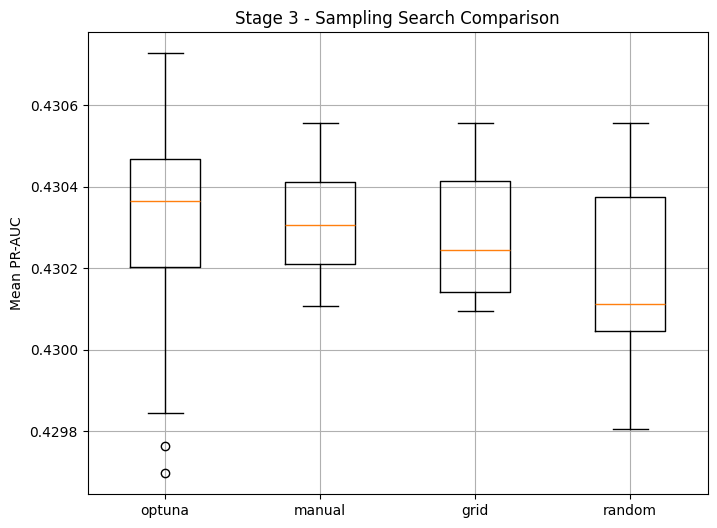

In [28]:
sampling_results_df = results_dataframe(
    SAMPLING_RESULTS
)

# Top results table
display(
    sampling_results_df.head(15)
)

# Variance box plot
plot_search_comparison(
    sampling_results_df,
    "Stage 3 - Sampling"
)

### Select & freeze best sampling parameters

In [29]:
best_sampling = sampling_results_df.iloc[0]

STAGE3_PARAMS = STAGE2_PARAMS.copy()

STAGE3_PARAMS.update(
    {
        "subsample": best_sampling["subsample"],
        "colsample_bytree": best_sampling["colsample_bytree"]
    }
)

STAGE3_PARAMS

{'objective': 'binary:logistic',
 'eval_metric': 'aucpr',
 'eta': np.float64(0.04679268676711243),
 'max_depth': 4,
 'min_child_weight': 10,
 'gamma': np.float64(0.5),
 'subsample': np.float64(0.572249573943548),
 'colsample_bytree': np.float64(0.8979068868124158),
 'reg_alpha': 0,
 'reg_lambda': 1,
 'scale_pos_weight': np.float64(16.39112801013942),
 'seed': 42,
 'n_jobs': -1}

---
## Stage 4: regularization parameters
- `reg_alpha`
- `reg_lambda`

In [30]:
STAGE = "regularization"

REG_RESULTS = []

def build_stage4_params(tuned_params):

    params = STAGE3_PARAMS.copy()

    params.update(
        tuned_params
    )

    return params

### Manual search for regularization parameters

In [31]:
manual_configs = [
    {"reg_alpha": 0, "reg_lambda": 1},
    {"reg_alpha": 0.1, "reg_lambda": 1},
    {"reg_alpha": 1, "reg_lambda": 5},
    {"reg_alpha": 5, "reg_lambda": 10}
]

for i, config in enumerate(manual_configs):

    params = build_stage4_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage4_manual_{i}",
        search_method="manual",
        stage=STAGE
    )

    result.update(config)
    REG_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Manual search completed")

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Manual search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Random search for regularization parameters

In [32]:
random_configs = list(
    ParameterSampler(
        {
            "reg_alpha": [0, 0.01, 0.1, 0.5, 1, 5, 10],
            "reg_lambda": [0.1, 1, 2, 5, 10, 20]
        },
        n_iter=15,
        random_state=42
    )
)

print(f"Number of configs: {len(random_configs)}")

for i, config in enumerate(random_configs):

    params = build_stage4_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage4_random_{i}",
        search_method="random",
        stage=STAGE
    )

    result.update(config)
    REG_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Random search completed")

Number of configs: 15


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Random search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Grid search for regularization parameters

In [33]:
grid_configs = list(
    ParameterGrid(
        {
            "reg_alpha": [0, 0.1, 1, 5],
            "reg_lambda": [1, 5, 10, 20]
        }
    )
)

print(f"Number of configs: {len(grid_configs)}")

for i, config in enumerate(grid_configs):

    params = build_stage4_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage4_grid_{i}",
        search_method="grid",
        stage=STAGE
    )

    result.update(config)
    REG_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

print("Grid search completed")

Number of configs: 16


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

Grid search completed


c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


### Optuna for regularization parameters

In [34]:
def optuna_reg_objective(trial):

    config = {
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.1,
            20,
            log=True
        )
    }

    params = build_stage4_params(config)

    result = evaluate_params(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        run_name=f"stage4_optuna_{trial.number}",
        search_method="optuna",
        stage=STAGE
    )

    result.update(config)
    REG_RESULTS.append(result)

    log_run(
        params=params,
        num_boost_round=STAGE1_BOOST_ROUND,
        result=result
    )

    return result["pr_auc_mean"]

# Run optuna
study = optuna.create_study(
    direction="maximize",
    study_name="stage4_regularization"
)

study.optimize(
    optuna_reg_objective,
    n_trials=50
)

print(study.best_params)
print(study.best_value)

[I 2026-07-17 04:41:51,989] A new study created in memory with name: stage4_regularization
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer 

{'reg_alpha': 5.899704244372543, 'reg_lambda': 0.2755180255209402}
0.4310052860503135


### Stage 4 results and comparison

,run_name,stage,search_method,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,reg_alpha,reg_lambda
0,stage4_optuna_31,regularization,optuna,0.431005,0.011259,0.867348,0.002927,5.899704,0.275518
1,stage4_optuna_36,regularization,optuna,0.430962,0.010956,0.867503,0.002858,6.813670,0.585599
2,stage4_optuna_17,regularization,optuna,0.430953,0.011088,0.867529,0.002867,5.947917,0.835105
3,stage4_optuna_46,regularization,optuna,0.430949,0.011055,0.867525,0.002859,9.548838,0.667804
4,stage4_optuna_12,regularization,optuna,0.430946,0.011184,0.867559,0.002761,1.918797,0.237697
5,stage4_optuna_49,regularization,optuna,0.430943,0.011282,0.867460,0.002854,5.552517,0.734666
6,stage4_optuna_19,regularization,optuna,0.430941,0.011094,0.867546,0.002837,9.927340,0.275323
7,stage4_optuna_35,regularization,optuna,0.430933,0.011154,0.867485,0.002780,5.096920,0.218006
8,stage4_optuna_25,regularization,optuna,0.430925,0.011073,0.867498,0.002685,6.077267,0.272031
9,stage4_random_8,regularization,random,0.430918,0.011105,0.867514,0.002823,5.000000,0.100000


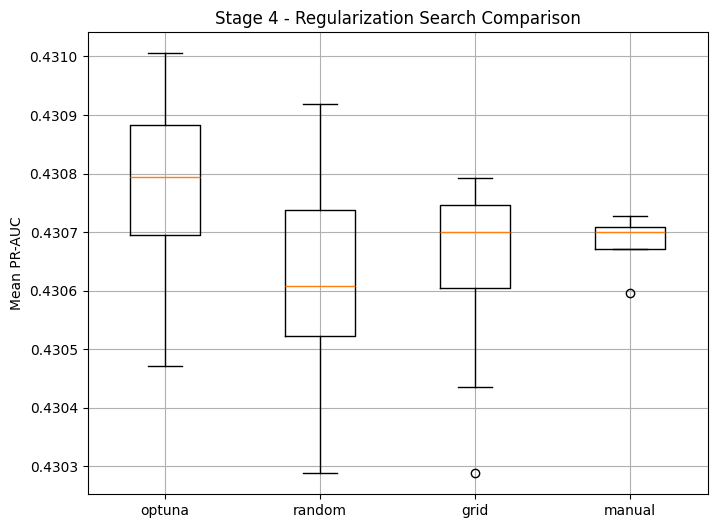

In [35]:
reg_results_df = results_dataframe(
    REG_RESULTS
)

# Top results table
display(
    reg_results_df.head(15)
)

# Variance box plot
plot_search_comparison(
    reg_results_df,
    "Stage 4 - Regularization"
)

### Select & freeze best parameters

In [36]:
best_reg = reg_results_df.iloc[0]

FINAL_PARAMS = STAGE3_PARAMS.copy()

FINAL_PARAMS.update(
    {
        "reg_alpha": best_reg["reg_alpha"],
        "reg_lambda": best_reg["reg_lambda"]
    }
)

FINAL_PARAMS

{'objective': 'binary:logistic',
 'eval_metric': 'aucpr',
 'eta': np.float64(0.04679268676711243),
 'max_depth': 4,
 'min_child_weight': 10,
 'gamma': np.float64(0.5),
 'subsample': np.float64(0.572249573943548),
 'colsample_bytree': np.float64(0.8979068868124158),
 'reg_alpha': np.float64(5.899704244372543),
 'reg_lambda': np.float64(0.2755180255209402),
 'scale_pos_weight': np.float64(16.39112801013942),
 'seed': 42,
 'n_jobs': -1}

---
### Save final parameters

In [37]:
final_config = {
    "params": FINAL_PARAMS,
    "num_boost_round": STAGE1_BOOST_ROUND
}

with open(
    BEST_PARAMS_PATH,
    "w"
) as f:
    json.dump(
        final_config,
        f,
        indent=4
    )

print(
    f"Saved to {BEST_PARAMS_PATH}"
)

Saved to c:\Users\ali.farhat\Documents\simbox-project\data\results\best_xgb_params.json


### Log to MLflow

In [38]:
with mlflow.start_run(
    run_name="final_hyperparameter_configuration"
):

    mlflow.log_param(
        "dataset",
        "train_v3"
    )

    mlflow.log_param(
        "selection_stage",
        "four_stage_sequential_tuning"
    )

    mlflow.log_params(
        FINAL_PARAMS
    )

    mlflow.log_param(
        "num_boost_round",
        STAGE1_BOOST_ROUND
    )

print("Final configuration logged")

Final configuration logged
